In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("/content/housing.csv")
print("Dataset uploaded successfully...")

Dataset uploaded successfully...


In [ ]:
print(df.shape)


(20640, 10)


In [ ]:
print(df.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')


In [ ]:
#Step 4: Dataset Information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None


In [ ]:
#Step 5: Summary Statistics
print(df.describe())


          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20640.000000  20640.000000  20640.000000   20640.000000   
mean       536.838857   1425.476744    499.539680       3.870671   
std        419.391878   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.000000       0.499900   
25%        297.00000

In [ ]:
#Step 7: Duplicate Values
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [ ]:
#Step 6: Missing Values
print(df.isnull().sum())

longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms                0
population                    0
households                    0
median_income                 0
median_house_value            0
ocean_proximity_INLAND        0
ocean_proximity_ISLAND        0
ocean_proximity_NEAR BAY      0
ocean_proximity_NEAR OCEAN    0
dtype: int64


In [ ]:
# Impute missing values in 'total_bedrooms' with the median
df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)

/tmp/ipykernel_1489/706836486.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)


In [ ]:
import pandas as pd

# Reload the original dataset to ensure a clean state for preprocessing
df = pd.read_csv('/content/housing.csv')

# Impute missing values in 'total_bedrooms' with the median after reloading
df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)

# Convert categorical 'ocean_proximity' column into numerical values using one-hot encoding
df = pd.get_dummies(
    df,
    columns=['ocean_proximity'],
    drop_first=True # Drop the first category to avoid multicollinearity
)

/tmp/ipykernel_1489/2308632676.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)


In [ ]:
# Identify continuous numerical columns for outlier detection
# Exclude the one-hot encoded 'ocean_proximity' columns as outliers are not typically sought in binary features
continuous_numerical_cols = [
    'longitude', 'latitude', 'housing_median_age', 'total_rooms',
    'total_bedrooms', 'population', 'households', 'median_income',
    'median_house_value'
]

outlier_indices = set()

print("Detecting outliers using the IQR method for continuous numerical features:")

for col in continuous_numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Define outlier bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Find outliers in the current column
    col_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index

    # Add unique outlier indices to the set
    outlier_indices.update(col_outliers)

    if len(col_outliers) > 0:
        print(f"  Column '{col}': {len(col_outliers)} outliers detected.")
    else:
        print(f"  Column '{col}': No outliers detected.")

# Report total unique outlier rows
total_unique_outliers = len(outlier_indices)
percentage_outliers = (total_unique_outliers / len(df)) * 100 if len(df) > 0 else 0

print(f"\nTotal unique rows identified as outliers across all selected features: {total_unique_outliers}")
print(f"Percentage of total rows that contain at least one outlier: {percentage_outliers:.2f}%")


Detecting outliers using the IQR method for continuous numerical features:
  Column 'longitude': No outliers detected.
  Column 'latitude': No outliers detected.
  Column 'housing_median_age': No outliers detected.
  Column 'total_rooms': 1287 outliers detected.
  Column 'total_bedrooms': 1306 outliers detected.
  Column 'population': 1196 outliers detected.
  Column 'households': 1220 outliers detected.
  Column 'median_income': 681 outliers detected.
  Column 'median_house_value': 1071 outliers detected.

Total unique rows identified as outliers across all selected features: 3031
Percentage of total rows that contain at least one outlier: 14.69%


In [ ]:
print(f"Original DataFrame shape: {df.shape}")

# Remove rows identified as outliers
df_cleaned = df.drop(outlier_indices)

print(f"DataFrame shape after removing outliers: {df_cleaned.shape}")
print(f"Number of rows removed: {len(df) - len(df_cleaned)}")

# Update the main DataFrame 'df' with the cleaned version
df = df_cleaned.copy()

print("Outliers removed successfully. The DataFrame 'df' has been updated.")

Original DataFrame shape: (20640, 13)
DataFrame shape after removing outliers: (17609, 13)
Number of rows removed: 3031
Outliers removed successfully. The DataFrame 'df' has been updated.


In [ ]:
# Independent Variables (features)
X = df.drop(['median_house_value'], axis=1)
# Dependent Variable (target)
y = df['median_house_value']

print(X.head())
print(y.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   
5    -122.25     37.85                52.0        919.0           213.0   
6    -122.25     37.84                52.0       2535.0           489.0   

   population  households  median_income  ocean_proximity_INLAND  \
2       496.0       177.0         7.2574                   False   
3       558.0       219.0         5.6431                   False   
4       565.0       259.0         3.8462                   False   
5       413.0       193.0         4.0368                   False   
6      1094.0       514.0         3.6591                   False   

   ocean_proximity_ISLAND  ocean_proximity_NEAR BAY  \
2                   False                      True   
3                   False     

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
print("Intercept :", model.intercept_)

print("\nCoefficients:")

coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coef)

Intercept : -2107289.5547266183

Coefficients:
                       Feature    Coefficient
0                    longitude  -24832.637142
1                     latitude  -23456.265165
2           housing_median_age     873.702329
3                  total_rooms     -12.540932
4               total_bedrooms     141.078005
5                   population     -60.429096
6                   households     108.417199
7                median_income   39246.638037
8       ocean_proximity_INLAND  -36385.804476
9       ocean_proximity_ISLAND  157203.671202
10    ocean_proximity_NEAR BAY  -10153.830670
11  ocean_proximity_NEAR OCEAN   -2565.903982


In [ ]:
if X_test['total_bedrooms'].isnull().any():
    median_total_bedrooms_train = X_train['total_bedrooms'].median()
    X_test['total_bedrooms'].fillna(median_total_bedrooms_train, inplace=True)

y_pred = model.predict(X_test)
print(y_pred[:10])

[107049.33398968 248583.58667384 239496.57205105 113848.2244168
 111154.64283075 181508.41352089 336145.63917268 192365.41044875
 256063.49117158 140845.08015542]


In [ ]:
result = pd.DataFrame({
    "Actual Selling Price": y_test.values,
    "Predicted Selling Price": y_pred
})
print(result.head())

   Actual Selling Price  Predicted Selling Price
0               58800.0            107049.333990
1              224100.0            248583.586674
2              187500.0            239496.572051
3               70400.0            113848.224417
4              148000.0            111154.642831


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 43250.71272769481
Mean Squared Error (MSE): 3476449847.9445944
Root Mean Squared Error (RMSE): 58961.42678009577
R² Score: 0.6200183671236132


In [ ]:
train_score = model.score(X_train, y_train)

print("Training R² Score:", train_score)

Training R² Score: 0.6231831582441074


In [ ]:
test_score = model.score(X_test, y_test)

print("Testing R² Score:", test_score)

Testing R² Score: 0.6200183671236132


In [ ]:
print("Regression Equation:\n")

print(f"Selling Price = {model.intercept_:.2f}")

for feature, coef in zip(X.columns, model.coef_):
    print(f"+ ({coef:.2f} × {feature})")

Regression Equation:

Selling Price = -2107289.55
+ (-24832.64 × longitude)
+ (-23456.27 × latitude)
+ (873.70 × housing_median_age)
+ (-12.54 × total_rooms)
+ (141.08 × total_bedrooms)
+ (-60.43 × population)
+ (108.42 × households)
+ (39246.64 × median_income)
+ (-36385.80 × ocean_proximity_INLAND)
+ (157203.67 × ocean_proximity_ISLAND)
+ (-10153.83 × ocean_proximity_NEAR BAY)
+ (-2565.90 × ocean_proximity_NEAR OCEAN)


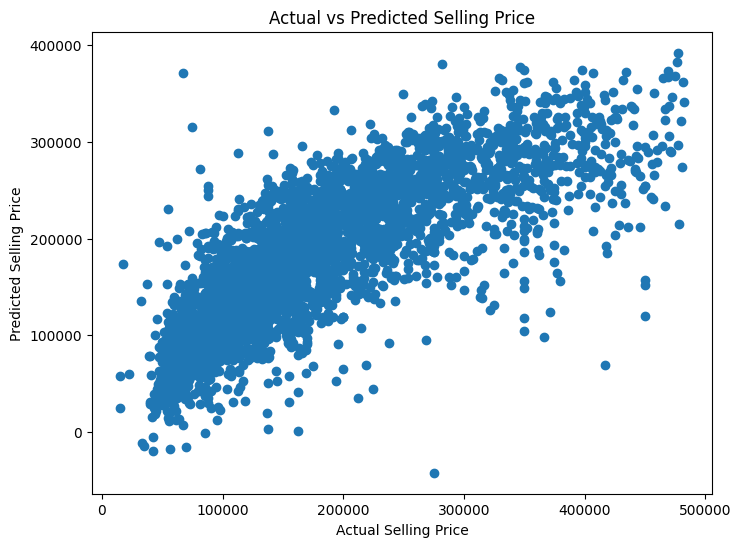

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")
plt.show()